# Trying algos with FloW_IMG dataset

In [26]:
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dropout, Flatten, Dense, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.optimizers import SGD
import keras
from sklearn.model_selection import train_test_split
import cv2
import os


In [28]:

# Define paths to your image folders (replace with your paths)
train_data_dir = 'D:/Engineering/SEM6/PROJECTS/DeepLearning/FloW_IMG/training/images'
validation_data_dir = 'D:/Engineering/SEM6/PROJECTS/DeepLearning/FloW_IMG/test/images'

# Set image dimensions (adjust if your images are different)
img_width, img_height = 224, 224

# Data augmentation for training data (optional but helpful)
train_datagen = ImageDataGenerator(rescale=1./255, shear_range=0.2, zoom_range=0.2, horizontal_flip=True)

# Load and pre-process training and validation data
train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_width, img_height),
    batch_size=32,  # Adjust batch size based on your GPU memory
    class_mode='categorical'  # Adjust for binary or multi-class classification
)

validation_datagen = ImageDataGenerator(rescale=1./255)
validation_generator = validation_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_width, img_height),
    batch_size=32,
    class_mode='categorical'
)


Found 0 images belonging to 0 classes.
Found 0 images belonging to 0 classes.


In [29]:

densenet_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))

for layer in densenet_model.layers:
  layer.trainable = False


In [30]:
x = densenet_model.output
x = Flatten()(x)
x = Dense(1024, activation='relu')(x)  
x = Dropout(0.5)(x)  
predictions = Dense(len(train_generator.classes), activation='softmax')(x) 

# Create the final model
model = Model(inputs=densenet_model.input, outputs=predictions)

# Compile the model (adjust optimizer and loss function as needed)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


NameError: name 'Model' is not defined

In [11]:
from ultralytics import YOLO
import ultralytics

# ultralytics.checks()

model = YOLO("yolov8n.yaml")

results = model.train(data = "config.yaml", epochs =1)



Ultralytics YOLOv8.1.38 🚀 Python-3.11.2 torch-2.2.2+cpu CPU (AMD Ryzen 7 5700G with Radeon Graphics)
Setup complete ✅ (16 CPUs, 31.9 GB RAM, 407.8/931.5 GB disk)


In [19]:
import cv2
import os
import random as random
from PIL import Image
from pascal import annotation_from_xml
import xml.etree.ElementTree as ET
import yaml
import random as random
import shutil
import matplotlib.pyplot as plt
import torch
import xml.etree.ElementTree as ET

In [32]:
# Function to convert XML annotations to YOLO format
def convert_xml_to_yolo(xml_folder, output_folder, class_mapping):
    # Create output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)

    # Loop through each XML file in the XML folder
    for xml_file in os.listdir(xml_folder):
        if xml_file.endswith('.xml'):
            xml_path = os.path.join(xml_folder, xml_file)
            # Parse XML
            tree = ET.parse(xml_path)
            root = tree.getroot()

            # Get image width and height
            size = root.find('size')
            width = int(size.find('width').text)
            height = int(size.find('height').text)

            # Create output file
            txt_file = os.path.splitext(xml_file)[0] + '.txt'
            txt_path = os.path.join(output_folder, txt_file)

            # Open output file
            with open(txt_path, 'w') as txt_file:
                # Loop through each object in XML
                for obj in root.findall('object'):
                    class_name = obj.find('name').text
                    # Check if class exists in class_mapping
                    if class_name in class_mapping:
                        class_id = class_mapping[class_name]
                        bbox = obj.find('bndbox')
                        xmin = float(bbox.find('xmin').text)
                        ymin = float(bbox.find('ymin').text)
                        xmax = float(bbox.find('xmax').text)
                        ymax = float(bbox.find('ymax').text)

                        # Convert bounding box coordinates to YOLO format
                        x_center = (xmin + xmax) / (2 * width)
                        y_center = (ymin + ymax) / (2 * height)
                        bbox_width = (xmax - xmin) / width
                        bbox_height = (ymax - ymin) / height

                        # Write to output file in YOLO format
                        txt_file.write(f"{class_id} {x_center} {y_center} {bbox_width} {bbox_height}\n")

# Example usage
xml_folder = 'D:\Engineering\SEM6\PROJECTS\DeepLearning\FloatingWaste-I-master\dataset_test\Annotations'   # Path to folder containing XML annotations
output_folder = 'D:\Engineering\SEM6\PROJECTS\DeepLearning\FloatingWaste-I-master\dataset_test\labels'  # Output folder for YOLO annotations
class_mapping = {'bottle':0, 'carton':1, 'plastic':2, 'paper':3}  # Mapping of class names to class IDs


convert_xml_to_yolo(xml_folder, output_folder, class_mapping)



New https://pypi.org/project/ultralytics/8.1.40 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.1.38 🚀 Python-3.11.2 torch-2.2.2+cpu CPU (AMD Ryzen 7 5700G with Radeon Graphics)
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=D:/Engineering/SEM6/PROJECTS/DeepLearning/FloW_IMG/config.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train9, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None,


train: Scanning D:\Engineering\SEM6\PROJECTS\DeepLearning\FloW_IMG\training\labels...:   0%|          | 0/1200 [00:00<?, ?it/s]
train: Scanning D:\Engineering\SEM6\PROJECTS\DeepLearning\FloW_IMG\training\labels... 0 images, 582 backgrounds, 0 corrupt:  48%|████▊     | 582/1200 [00:00<00:00, 5649.06it/s]
train: Scanning D:\Engineering\SEM6\PROJECTS\DeepLearning\FloW_IMG\training\labels... 0 images, 1200 backgrounds, 0 corrupt: 100%|██████████| 1200/1200 [00:00<00:00, 6113.54it/s]

val: Scanning D:\Engineering\SEM6\PROJECTS\DeepLearning\FloW_IMG\test\labels...:   0%|          | 0/800 [00:00<?, ?it/s]
val: Scanning D:\Engineering\SEM6\PROJECTS\DeepLearning\FloW_IMG\test\labels... 0 images, 638 backgrounds, 0 corrupt:  80%|███████▉  | 638/800 [00:00<00:00, 6365.27it/s]
val: Scanning D:\Engineering\SEM6\PROJECTS\DeepLearning\FloW_IMG\test\labels... 0 images, 800 backgrounds, 0 corrupt: 100%|██████████| 800/800 [00:00<00:00, 6595.58it/s]

  0%|          | 0/75 [00:00<?, ?it/s]
      1/100  

New https://pypi.org/project/ultralytics/8.1.40 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.1.38 🚀 Python-3.11.2 torch-2.2.2+cpu CPU (AMD Ryzen 7 5700G with Radeon Graphics)
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=D:/Engineering/SEM6/PROJECTS/DeepLearning/FloW_IMG/config.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train14, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None


train: Scanning D:\Engineering\SEM6\PROJECTS\DeepLearning\FloW_IMG\training\labels.cache... 0 images, 1200 backgrounds, 0 corrupt: 100%|██████████| 1200/1200 [00:00<?, ?it/s]
train: Scanning D:\Engineering\SEM6\PROJECTS\DeepLearning\FloW_IMG\training\labels.cache... 0 images, 1200 backgrounds, 0 corrupt: 100%|██████████| 1200/1200 [00:00<?, ?it/s]

val: Scanning D:\Engineering\SEM6\PROJECTS\DeepLearning\FloW_IMG\test\labels.cache... 0 images, 800 backgrounds, 0 corrupt: 100%|██████████| 800/800 [00:00<?, ?it/s]
val: Scanning D:\Engineering\SEM6\PROJECTS\DeepLearning\FloW_IMG\test\labels.cache... 0 images, 800 backgrounds, 0 corrupt: 100%|██████████| 800/800 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]
      1/100         0G          0      120.6          0          0        640:   0%|          | 0/75 [00:05<?, ?it/s]
      1/100         0G          0      120.6          0          0        640:   1%|▏         | 1/75 [00:05<07:06,  5.77s/it]
      1/100         0G          

In [30]:
!yolo task=detect mode=train model=yolov8n.pt data=D:/Engineering/SEM6/PROJECTS/DeepLearning/FloatingWaste-I-master/data.yaml

^C


Found 968 validated image filenames belonging to 1 classes.
Found 109 validated image filenames belonging to 1 classes.


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\legacy\preprocessing\image.py:920: UserWarning: Found 952 invalid image filename(s) in x_col="Image". These filename(s) will be ignored.
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\legacy\preprocessing\image.py:920: UserWarning: Found 131 invalid image filename(s) in x_col="Image". These filename(s) will be ignored.
  warnings.warn(


Epoch 1/5


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\ops\nn.py:545: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\losses\losses.py:22: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_mul

30/30 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/5
 1/30 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\contextlib.py:155: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


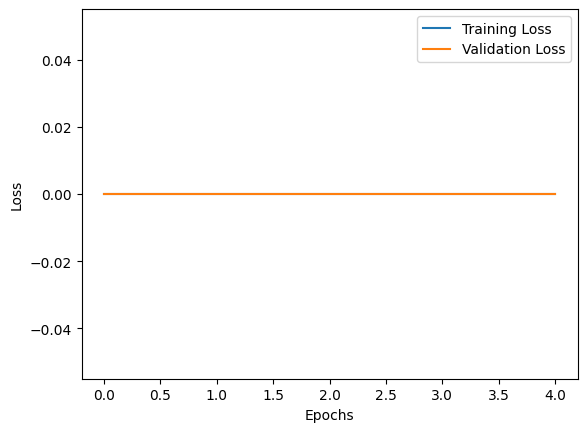

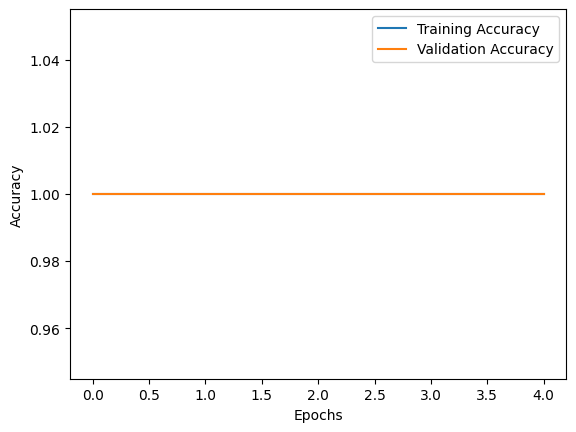

4/4 - 1s - 278ms/step - accuracy: 1.0000 - loss: 0.0000e+00

Test accuracy: 100.00%


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\ops\nn.py:545: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 759ms/step
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       109

    accuracy                           1.00       109
   macro avg       1.00      1.00      1.00       109
weighted avg       1.00      1.00      1.00       109



c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:386: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


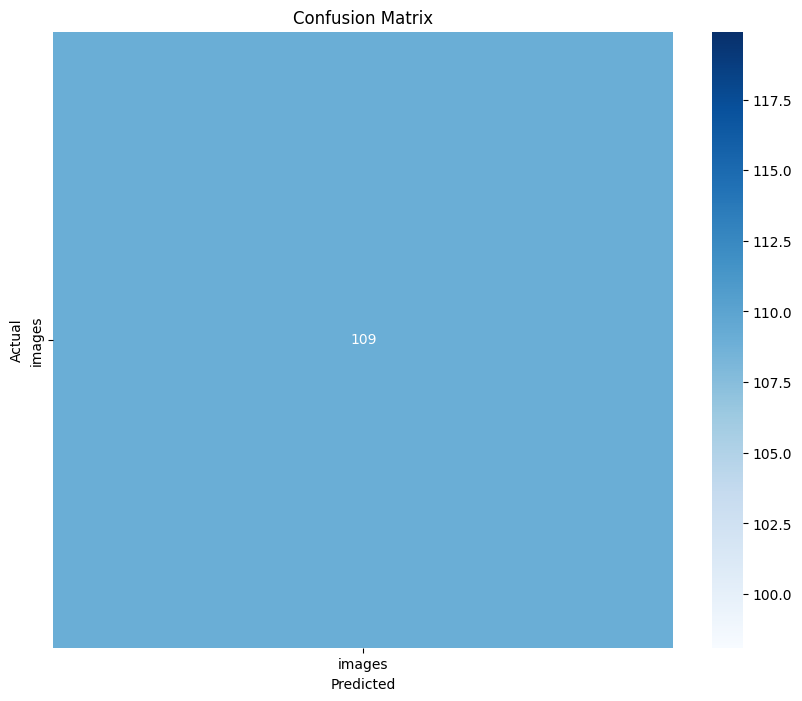

In [9]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications import EfficientNetV2B0
from keras.layers import Dense, GlobalAveragePooling2D
from keras.models import Model
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from keras.callbacks import EarlyStopping

# Define function to load images and labels
def load_images_and_labels(root_folder):
    images = []
    labels = []

    # Iterate through each folder
    for class_folder in os.listdir(root_folder):
        class_folder_path = os.path.join(root_folder, class_folder)

        # Check if it's a directory
        if os.path.isdir(class_folder_path):
            # Iterate through each image file in the folder
            for image_file in os.listdir(class_folder_path):
                image_path = os.path.join(class_folder_path, image_file)
                images.append(image_path)
                labels.append(class_folder)

    return images, labels

# Define paths
root_folder_path = 'D:/Engineering/SEM6/PROJECTS/DeepLearning/FloW_IMG/training'

# Load images and labels
images, labels = load_images_and_labels(root_folder_path)

# Split data into train, validation, and test sets
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

# Create DataFrames
train_df = pd.DataFrame({'Image': X_train, 'Label': y_train})
val_df = pd.DataFrame({'Image': X_val, 'Label': y_val})
test_df = pd.DataFrame({'Image': X_test, 'Label': y_test})

# Parameters
batch_size = 32
epochs = 5  # Increase the number of epochs for better training
input_shape = (224, 224, 3)

# Create data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1. / 255)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='Image',
    y_col='Label',
    target_size=(input_shape[0], input_shape[1]),
    batch_size=batch_size,
    class_mode='categorical'
)

validation_generator = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col='Image',
    y_col='Label',
    target_size=(input_shape[0], input_shape[1]),
    batch_size=batch_size,
    class_mode='categorical'
)

# validation_generator = val_test_datagen.flow_from_dataframe(
#     test_df,
#     x_col='Image',
#     y_col='Label',
#     target_size=(input_shape[0], input_shape[1]),
#     batch_size=batch_size,
#     class_mode='categorical'
# )

# Load pre-trained EfficientNetB0 model
base_model = EfficientNetV2B0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)  # Adding dropout for regularization
predictions = Dense(len(train_generator.class_indices), activation='softmax')(x)

# Combine base model and custom layers
model = Model(inputs=base_model.input, outputs=predictions)

# Unfreeze some layers of base model for fine-tuning
for layer in base_model.layers[-20:]:
    layer.trainable = True

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, verbose=1)

# Train the model with early stopping and class weights
class_weights = {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0, 8: 1.0, 9: 1.0, 10: 1.0, 11: 1.0}  # Modify as per your class distribution
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    epochs=epochs,
    callbacks=[early_stopping],
    class_weight=class_weights  # Apply class weights during training
)

# Plot loss and accuracy curves
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(validation_generator, verbose=2)
print("\nTest accuracy: {:.2f}%".format(test_acc * 100))

# Predictions on test set
y_pred = model.predict(validation_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
true_classes = validation_generator.classes

# Classification Report
print("Classification Report:")
print(classification_report(true_classes, y_pred_classes))

# Confusion Matrix
cm = confusion_matrix(true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=validation_generator.class_indices.keys(), yticklabels=validation_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
